# Question 4 — Suggestion automatique d'orientation

**Fichier :** `src/models/classification_orientation_q4.py`

Classification **supervisée** : prédire `target` (littéraire / scientifique) à partir de **Notes** et **Assiduité**.

Classifieurs comparés : régression logistique, arbre de décision, KNN (k=5).

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().resolve()
if RACINE.name == "notebooks":
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
from src.data.chargement import charger_donnees_brutes, chemin_figures
from src.models.classification_orientation_q4 import executer_classification

df = charger_donnees_brutes()
print(f"Effectifs — littéraire (0) : {(df['target']==0).sum()} | scientifique (1) : {(df['target']==1).sum()}")
df.head()

Effectifs — littéraire (0) : 503 | scientifique (1) : 497


,Notes,Assiduité,target
0,14.5,69.0,1
1,3.7,16.0,0
2,9.8,48.0,0
3,7.0,38.0,0
4,3.3,21.0,0


## Exécution du pipeline Q4

In [2]:
resultats = executer_classification()

resultats["comparaison_classifieurs"][
    ["rang", "modele", "accuracy_test", "precision_test", "recall_test", "f1_test", "auc_test"]
]

,rang,modele,accuracy_test,precision_test,recall_test,f1_test,auc_test
0,1,Arbre de décision,1.00,1.0,1.000000,1.000000,1.0000
1,2,Régression logistique,0.99,1.0,0.979798,0.989796,0.9994
2,3,KNN (k=5),0.99,1.0,0.979798,0.989796,0.9997


In [3]:
cv = resultats["validation_croisee"]
print(f"Meilleur classifieur (F1) : {resultats['meilleur_modele']['nom']}")
print(f"Accuracy = {resultats['meilleur_modele']['accuracy']:.1%} | F1 = {resultats['meilleur_modele']['f1']:.3f}")
print(f"Validation croisée (log. régression, 5 blocs) : F1 = {cv['f1_moyen']:.3f} ± {cv['f1_ecart']:.3f}")
print(f"\n{resultats['message_confiance']}")
print("\nMatrice de confusion (arbre de décision) :")
print(resultats["matrice_arbre"])

Meilleur classifieur (F1) : Arbre de décision
Accuracy = 100.0% | F1 = 1.000
Validation croisée (log. régression, 5 blocs) : F1 = 0.989 ± 0.010

Précision globale = 100.0% : scores élevés sur nos données, mais à relativiser (cible construite par un seuil d'assiduité).

Matrice de confusion (arbre de décision) :
[[101   0]
 [  0  99]]


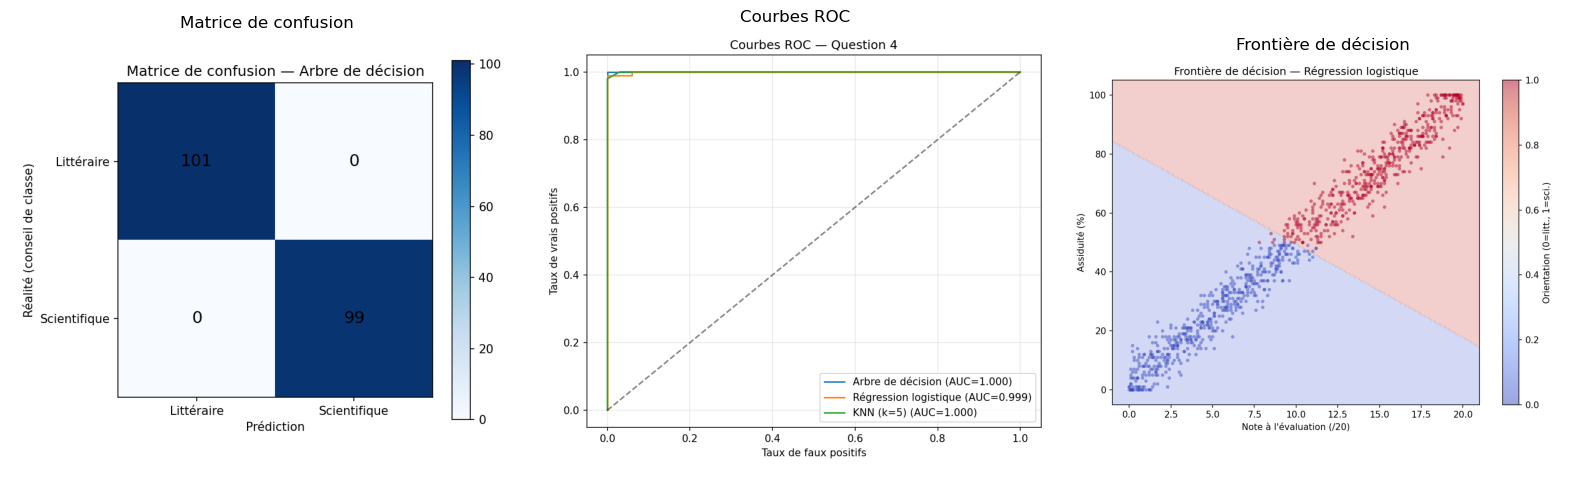

In [4]:
dossier = chemin_figures()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
figures = [
    ("matrice_confusion_q4.png", "Matrice de confusion"),
    ("courbe_roc_q4.png", "Courbes ROC"),
    ("frontiere_decision_q4.png", "Frontière de décision"),
]
for ax, (fichier, titre) in zip(axes, figures):
    ax.imshow(plt.imread(dossier / fichier))
    ax.axis("off")
    ax.set_title(titre)
plt.tight_layout()
plt.show()

## Interprétation pour le proviseur

- **Apprentissage supervisé** : on prédit l'orientation (`target`) à partir de Notes et Assiduité.
- Les scores élevés tiennent en partie à la génération des données (`target = 1` si Assiduité ≥ 50 %).
- **Recommandation** : outil d'aide à la décision uniquement, jamais de décision automatique sans le conseil de classe.

In [5]:
for risque in resultats["risques_pedagogiques"]:
    print(f"- {risque}")

- Performances élevées liées au seuil artificiel target = (Assiduité >= 50%).
- L'orientation réelle repose sur bien plus que deux variables.
- Risque d'automatisation excessive (automation bias) si le score est pris pour une certitude.
- Le modèle peut reproduire des biais historiques du conseil de classe.
